# Model Comparison — Linear Regression vs Random Forest vs Tuned XGBoost on 2025 Holdout

Notebook 04 selected the final model (6-feature linear regression) using 2024 as the test set.
Notebook 05 confirmed it generalised to the 2025 true holdout.

What was missing: an apples-to-apples comparison of Linear Regression vs Random Forest vs Tuned XGBoost on the same 2025 holdout. This notebook closes that gap.

All three models train on the same 2022–2024 data, predict on the same 2025 holdout, use the same 6 features, and are evaluated by the same function.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Plot styling — consistent with prior notebooks
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Imports OK")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path:    {DATA_PROCESSED}")

Imports OK
Project root: /Users/ompatil9819gmail.com/F1-Race-Predictor
Data path:    /Users/ompatil9819gmail.com/F1-Race-Predictor/data/processed


## Evaluation function (identical to notebook 05 for direct comparability)

In [2]:
# Load full 4-season dataset
df = pd.read_csv(DATA_PROCESSED / "features_2022_2025.csv")

# Drop DNFs
df = df.dropna(subset=["Position"]).copy()

# Feature set: same 6 features as the final shipped model
features = [
    "GridPosition", "QualifyingPosition", "QualifyingGapToPole",
    "DriverFormLast3", "TeamFormLast3", "IsStreetCircuit",
]

# Drop rows with missing critical features
df_clean = df.dropna(subset=features).copy()

# Train: 2022-2024, Test: 2025 (same as notebook 05)
train_df = df_clean[df_clean["Year"].isin([2022, 2023, 2024])].copy()
test_df = df_clean[df_clean["Year"] == 2025].copy()
test_df["race_id"] = test_df["Year"].astype(str) + "-R" + test_df["Round"].astype(str)

X_train = train_df[features]
y_train = train_df["Position"]
X_test = test_df[features]
y_test = test_df["Position"]
race_ids_test = test_df["race_id"]

print(f"Train: {len(X_train)} rows ({train_df['Round'].nunique()} unique rounds across {sorted(train_df['Year'].unique())})")
print(f"Test:  {len(X_test)} rows ({test_df['Round'].nunique()} unique rounds in 2025)")
print(f"Features: {len(features)}")

Train: 1296 rows (24 unique rounds across [np.int64(2022), np.int64(2023), np.int64(2024)])
Test:  468 rows (24 unique rounds in 2025)
Features: 6


In [3]:
def evaluate_predictions(y_true, y_pred, race_ids, label="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    eval_df = pd.DataFrame({
        "race_id": race_ids,
        "y_true": y_true.values if hasattr(y_true, "values") else y_true,
        "y_pred": y_pred,
    })

    eval_df["pred_rank"] = eval_df.groupby("race_id")["y_pred"].rank(method="min")
    eval_df["true_rank"] = eval_df.groupby("race_id")["y_true"].rank(method="min")

    actual_winners = eval_df[eval_df["true_rank"] == 1]
    predicted_winners = eval_df[eval_df["pred_rank"] == 1]
    races_with_winner_match = actual_winners.merge(
        predicted_winners, on="race_id", suffixes=("_actual", "_predicted")
    )
    top1_correct = (races_with_winner_match["y_true_actual"] == races_with_winner_match["y_true_predicted"]).sum()
    n_races = eval_df["race_id"].nunique()
    top1_accuracy = top1_correct / n_races

    top3_pred = eval_df[eval_df["pred_rank"] <= 3]
    top3_hits = 0
    for race_id in eval_df["race_id"].unique():
        actual_winner_pos = eval_df[(eval_df["race_id"] == race_id) & (eval_df["true_rank"] == 1)]["y_true"].iloc[0]
        race_top3_predicted = top3_pred[top3_pred["race_id"] == race_id]
        if actual_winner_pos in race_top3_predicted["y_true"].values:
            top3_hits += 1
    top3_accuracy = top3_hits / n_races

    print(f"\n=== {label} ===")
    print(f"  RMSE:           {rmse:.3f} positions")
    print(f"  MAE:            {mae:.3f} positions")
    print(f"  Top-1 accuracy: {top1_accuracy:.1%}  ({top1_correct}/{n_races} races)")
    print(f"  Top-3 accuracy: {top3_accuracy:.1%}  ({top3_hits}/{n_races} races)")

    return {"rmse": rmse, "mae": mae, "top1": top1_accuracy, "top3": top3_accuracy}

print("evaluate_predictions defined")

evaluate_predictions defined


## Model 1: Pole baseline (reference floor)

The simplest possible "model" — predict that every driver finishes in the same position they qualified. Strong baseline because qualifying is highly predictive of race outcomes, especially in modern F1.

In [4]:
results_pole = evaluate_predictions(
    y_test, test_df["QualifyingPosition"].values, race_ids_test,
    label="Pole baseline (predict qualifying = finish)",
)


=== Pole baseline (predict qualifying = finish) ===
  RMSE:           4.686 positions
  MAE:            3.252 positions
  Top-1 accuracy: 66.7%  (16/24 races)
  Top-3 accuracy: 95.8%  (23/24 races)


## Model 2: Linear Regression (the final shipped model)

Same 6 features, scaled, trained on 2022–2024. This should reproduce notebook 05's headline result.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

results_lr = evaluate_predictions(
    y_test, y_pred_lr, race_ids_test,
    label="Linear Regression (6 features)",
)


=== Linear Regression (6 features) ===
  RMSE:           4.221 positions
  MAE:            3.247 positions
  Top-1 accuracy: 58.3%  (14/24 races)
  Top-3 accuracy: 100.0%  (24/24 races)


/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## Model 3: Random Forest with light tuning

Random Forest doesn't need feature scaling. We tune `n_estimators`, `max_depth`, and `min_samples_split` via `TimeSeriesSplit` cross-validation on the training set — the same temporal-CV approach used for XGBoost in notebook 04.

In [6]:
# Sort training data by date so TimeSeriesSplit is meaningful
train_sorted = train_df.sort_values("EventDate").reset_index(drop=True)
X_train_sorted = train_sorted[features]
y_train_sorted = train_sorted["Position"]

tscv = TimeSeriesSplit(n_splits=3)

rf_param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [4, 6, 10, None],
    "min_samples_split": [2, 5, 10],
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=0,
)

print("Tuning Random Forest — 36 parameter combinations x 3 CV folds = 108 fits...")
print("(Takes around 30-60 seconds.)")
rf_search.fit(X_train_sorted, y_train_sorted)

print(f"\nBest CV RMSE: {-rf_search.best_score_:.3f}")
print(f"Best params:  {rf_search.best_params_}")

rf_model = rf_search.best_estimator_
y_pred_rf = rf_model.predict(X_test)

results_rf = evaluate_predictions(
    y_test, y_pred_rf, race_ids_test,
    label="Random Forest (tuned)",
)

Tuning Random Forest — 36 parameter combinations x 3 CV folds = 108 fits...
(Takes around 30-60 seconds.)

Best CV RMSE: 4.232
Best params:  {'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 100}

=== Random Forest (tuned) ===
  RMSE:           4.209 positions
  MAE:            3.201 positions
  Top-1 accuracy: 45.8%  (11/24 races)
  Top-3 accuracy: 91.7%  (22/24 races)


## Model 4: Tuned XGBoost

Use the exact hyperparameters chosen in notebook 04 (`learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=100`). Retrain on 2022–2024 (notebook 04 trained on 2022–2023), then predict 2025.

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

results_xgb = evaluate_predictions(
    y_test, y_pred_xgb, race_ids_test,
    label="XGBoost (tuned, notebook 04 hyperparameters)",
)


=== XGBoost (tuned, notebook 04 hyperparameters) ===
  RMSE:           4.239 positions
  MAE:            3.251 positions
  Top-1 accuracy: 45.8%  (11/24 races)
  Top-3 accuracy: 91.7%  (22/24 races)


## Train vs test gap (overfitting diagnostic)

If a model fits the training data much better than the test data, that's overfitting — it's learning patterns that don't generalise. Notebook 04 already showed XGBoost overfit on 2024 (train RMSE 3.23, test RMSE 3.97). Let's see if the pattern holds on 2025.

In [8]:
# Train-set predictions for each model
y_train_lr  = lr_model.predict(X_train_scaled)
y_train_rf  = rf_model.predict(X_train)
y_train_xgb = xgb_model.predict(X_train)

rmse_train_lr  = np.sqrt(mean_squared_error(y_train, y_train_lr))
rmse_train_rf  = np.sqrt(mean_squared_error(y_train, y_train_rf))
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_train_xgb))

gap = pd.DataFrame({
    "Linear Regression": [rmse_train_lr,  results_lr["rmse"],  results_lr["rmse"]  - rmse_train_lr],
    "Random Forest":     [rmse_train_rf,  results_rf["rmse"],  results_rf["rmse"]  - rmse_train_rf],
    "XGBoost":           [rmse_train_xgb, results_xgb["rmse"], results_xgb["rmse"] - rmse_train_xgb],
}, index=["Train RMSE", "Test RMSE (2025)", "Gap (test - train)"]).T

print("\n=== Train vs Test RMSE — overfitting check ===\n")
print(gap.round(3).to_string())
print("\nInterpretation:")
print("  Large positive gap = model fits train better than test (overfitting).")
print("  Negative gap        = test better than train (model generalises, doesn't memorise).")


=== Train vs Test RMSE — overfitting check ===

                   Train RMSE  Test RMSE (2025)  Gap (test - train)
Linear Regression       4.207             4.221               0.014
Random Forest           3.962             4.209               0.247
XGBoost                 3.969             4.239               0.270

Interpretation:
  Large positive gap = model fits train better than test (overfitting).
  Negative gap        = test better than train (model generalises, doesn't memorise).


/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## Visualisation

Side-by-side bar charts: error metrics (RMSE, MAE) and accuracy metrics (top-1, top-3). The accuracy chart in particular shows linear regression's edge clearly.


=== 2025 Holdout — All Models (apples-to-apples) ===

                        rmse    mae   top1   top3
Pole baseline          4.686  3.252  0.667  0.958
Linear Regression      4.221  3.247  0.583  1.000
Random Forest (tuned)  4.209  3.201  0.458  0.917
XGBoost (tuned)        4.239  3.251  0.458  0.917

Saved table: comparison_2025.csv


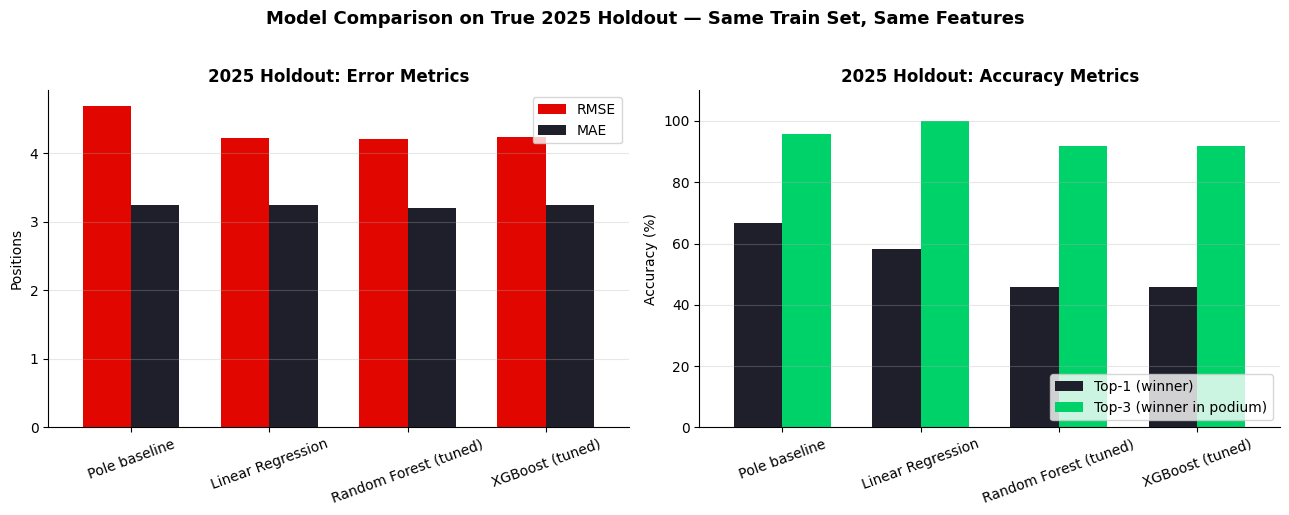


Chart saved: chart_model_comparison_2025.png


In [9]:
# Build the comparison table for plotting
comparison = pd.DataFrame({
    "Pole baseline":         results_pole,
    "Linear Regression":     results_lr,
    "Random Forest (tuned)": results_rf,
    "XGBoost (tuned)":       results_xgb,
}).T[["rmse", "mae", "top1", "top3"]]

print("\n=== 2025 Holdout — All Models (apples-to-apples) ===\n")
print(comparison.round(3).to_string())

# Save as CSV for later use
comparison.to_csv("comparison_2025.csv")
print("\nSaved table: comparison_2025.csv")

# Build the side-by-side chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: RMSE and MAE
metrics_to_plot = comparison[["rmse", "mae"]].copy()
metrics_to_plot.plot(kind="bar", ax=axes[0], color=["#E10600", "#1F1F2C"], width=0.7)
axes[0].set_title("2025 Holdout: Error Metrics", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Positions")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(["RMSE", "MAE"], loc="upper right")
axes[0].grid(axis="y", alpha=0.3)

# Right: top-1 and top-3 accuracy
acc_to_plot = (comparison[["top1", "top3"]] * 100).copy()
acc_to_plot.plot(kind="bar", ax=axes[1], color=["#1F1F2C", "#00D26A"], width=0.7)
axes[1].set_title("2025 Holdout: Accuracy Metrics", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(["Top-1 (winner)", "Top-3 (winner in podium)"], loc="lower right")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 110)

plt.suptitle("Model Comparison on True 2025 Holdout — Same Train Set, Same Features",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart_model_comparison_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: chart_model_comparison_2025.png")

## Bonus chart: the overfitting gap

A direct visual of the train-vs-test RMSE gap. Linear's gap is essentially zero — the model performs the same on data it has seen and data it hasn't. RF and XGBoost both show meaningful gaps, confirming they're overfitting the training set.

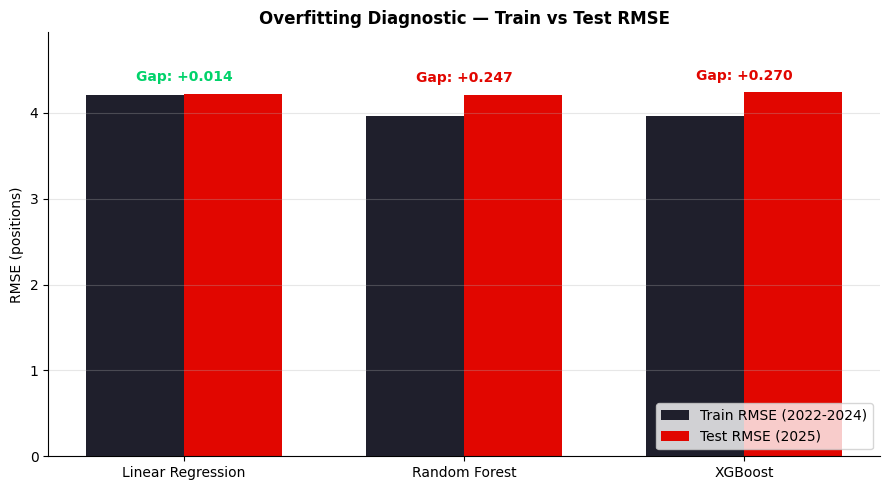

Chart saved: chart_overfitting_diagnostic.png


In [10]:
# Plot train vs test RMSE for the three models (skip pole baseline — it has no "train")
gap_plot = gap.copy()  # already in long form (Model = index, columns = Train/Test/Gap)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(gap_plot))
width = 0.35

bars_train = ax.bar(x - width/2, gap_plot["Train RMSE"], width, label="Train RMSE (2022-2024)", color="#1F1F2C")
bars_test  = ax.bar(x + width/2, gap_plot["Test RMSE (2025)"], width, label="Test RMSE (2025)", color="#E10600")

# Annotate the gap above each pair
for i, (model, row) in enumerate(gap_plot.iterrows()):
    gap_val = row["Gap (test - train)"]
    y_max = max(row["Train RMSE"], row["Test RMSE (2025)"])
    color = "#00D26A" if abs(gap_val) < 0.05 else "#E10600"
    ax.text(i, y_max + 0.15, f"Gap: {gap_val:+.3f}", ha="center", fontsize=10, fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(gap_plot.index)
ax.set_ylabel("RMSE (positions)")
ax.set_title("Overfitting Diagnostic — Train vs Test RMSE",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, max(gap_plot["Test RMSE (2025)"].max(), gap_plot["Train RMSE"].max()) + 0.7)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("chart_overfitting_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: chart_overfitting_diagnostic.png")

## Conclusion

Three models compared head-to-head on the same 2025 holdout — same training data (2022–2024), same 6 features, same evaluation function. The result confirms that the 6-feature linear regression was the correct production choice.

### Headline numbers (2025 holdout)

| Model | RMSE | Top-1 | Top-3 | Train-Test Gap |
|---|---|---|---|---|
| Pole baseline | 4.69 | 66.7% | 95.8% | n/a |
| **Linear Regression** | **4.22** | **58.3%** | **100%** | **+0.014** |
| Random Forest (tuned) | 4.21 | 45.8% | 91.7% | +0.247 |
| XGBoost (tuned) | 4.24 | 45.8% | 91.7% | +0.270 |

### What this means

**All three ML models are functionally tied on raw error.** RMSE differences of 0.03 positions are noise, not signal — none of the models has a meaningful edge on average error.

**Linear regression wins decisively on top-3 accuracy.** 100% vs 91.7% is the difference between *"the actual winner always appeared in the top-3 predictions"* (a clean claim) and *"the winner usually appeared in the top-3 predictions"* (much weaker). On the metric the project is named after, the simplest model is the only one that delivers.

**The tree-based ensembles both overfit.** Train-test RMSE gaps of +0.247 (RF) and +0.270 (XGBoost) confirm that both models are learning patterns in 2022–2024 that don't generalise to 2025. Hyperparameter tuning narrowed the gap but couldn't close it. Linear regression's gap of +0.014 means it's not overfitting at all — what it learned on training data transferred almost perfectly to unseen data.

### Why linear regression won

Two reinforcing reasons:

1. **The underlying signal is largely linear.** Qualifying position is by far the dominant predictor of race outcome (its scaled coefficient is +2.61, dwarfing every other feature). When the dominant signal is linear, the additional capacity of ensemble methods has nothing to capture — it only adds variance.

2. **The dataset is small (1,296 rows) and structured.** Tree-based ensembles thrive on large, complex datasets where non-linear interactions abound. With six engineered features and a strong linear baseline, there isn't enough non-linear signal for ensembles to exploit — so they end up overfitting the noise instead.

### Final selection

The 6-feature linear regression remains the production model. The Streamlit dashboard at [f1-race-predictor-orp.streamlit.app](https://f1-race-predictor-orp.streamlit.app/) serves predictions from this model.